# **Student Perormance Prediction (Math Grades)**
The dataset contains information regarding two schools and their student's performance in subjects : maths and portuguese. The dataset contains columns describing student grades, heath, parental information, time management and more. I will perform EDA and final model construction using G3 as its a greater performance metric for a student as the final year grade and may have correlation to other metrics discussed in the dataset.

This is an important data visualisation and modelling problem as predicting final year grade of a student beforehand may help determine which students are struggling and could allow teachers to better manage study sessions and provide personalised help to each.

### Dataset Imports and Preparation

This dataset contains student information from a math course. Each row represents one student, and each column represents a feature about that student. The dataset has about 397 rows and 33 columns.

The columns include school information, family background, student habits, and academic performance. Some examples of columns are school, sex, age, studytime, failures, absences, Medu, Fedu, internet, goout, and the grade columns.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from pprint import pprint
import os

In [92]:
if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None:
    print("running on kaggle")
    dataset_path = "/kaggle/input/datasets/whenamancodes/student-performance/Maths.csv"
    # the file is actually in xlsx (Microsoft Excel) format, despite the csv file extension
    math_perf = pd.read_excel(dataset_path)
else:
    print("running locally")
    dataset_path = "Maths.csv"
    math_perf = pd.read_csv(dataset_path)

running on kaggle


### Dataset Exploration and Exploratory Analysis

In [93]:
math_perf.info()

math_perf.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      397 non-null    object
 1   sex         397 non-null    object
 2   age         397 non-null    int64 
 3   address     397 non-null    object
 4   famsize     397 non-null    object
 5   Pstatus     397 non-null    object
 6   Medu        397 non-null    int64 
 7   Fedu        397 non-null    int64 
 8   Mjob        397 non-null    object
 9   Fjob        397 non-null    object
 10  reason      397 non-null    object
 11  guardian    397 non-null    object
 12  traveltime  397 non-null    int64 
 13  studytime   397 non-null    int64 
 14  failures    397 non-null    int64 
 15  schoolsup   397 non-null    object
 16  famsup      397 non-null    object
 17  paid        397 non-null    object
 18  activities  397 non-null    object
 19  nursery     397 non-null    object
 20  higher    

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [94]:
categorical_features = math_perf.select_dtypes(include=["object", "string"]).columns
numerical_features = math_perf.select_dtypes(include="number").columns

print("Categorical features:")
print(list(categorical_features))

print("\nNumerical features:")
print(list(numerical_features))

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [95]:
math_perf = math_perf.drop_duplicates()

In [96]:
math_perf.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [97]:
math_perf.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [98]:
math_perf.corr(numeric_only=True)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


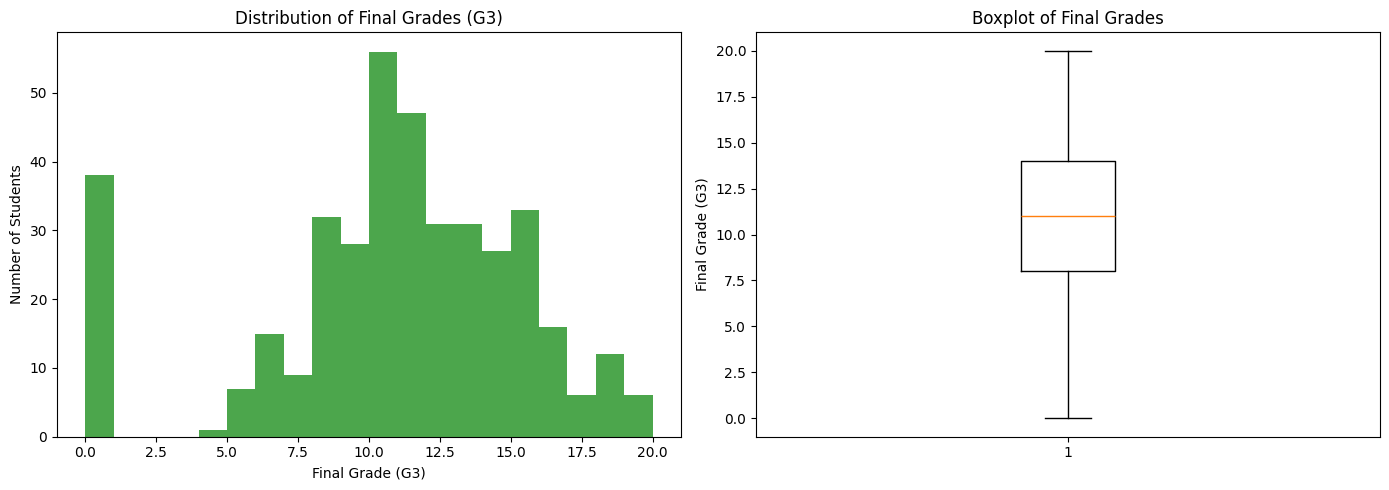

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(math_perf["G3"], bins=20, color='green', alpha=0.7)
ax[0].set_title("Distribution of Final Grades (G3)")
ax[0].set_xlabel("Final Grade (G3)")
ax[0].set_ylabel("Number of Students")

ax[1].boxplot(math_perf["G3"])
ax[1].set_title("Boxplot of Final Grades")
ax[1].set_ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

The histogram illustrates the distribution of final grades (G3), revealing that the majority of students scored between approximately 8 and 16, with a heavy concentration in the 10–12 range. Notably, a distinct cluster of students received a grade of 0, likely indicating failures or dropouts. Because these outliers could skew predictive modeling, they warrant careful consideration during data analysis.

The boxplot showcases the distribution of final grades (G3). most students scored 8-14 with the median of data around 11. The lowest value is 0 and the highest value is 20, so there is a wide range of data available for final grades. There are no outliers in the dataset according to the plot yet low scores are especially important while training the model

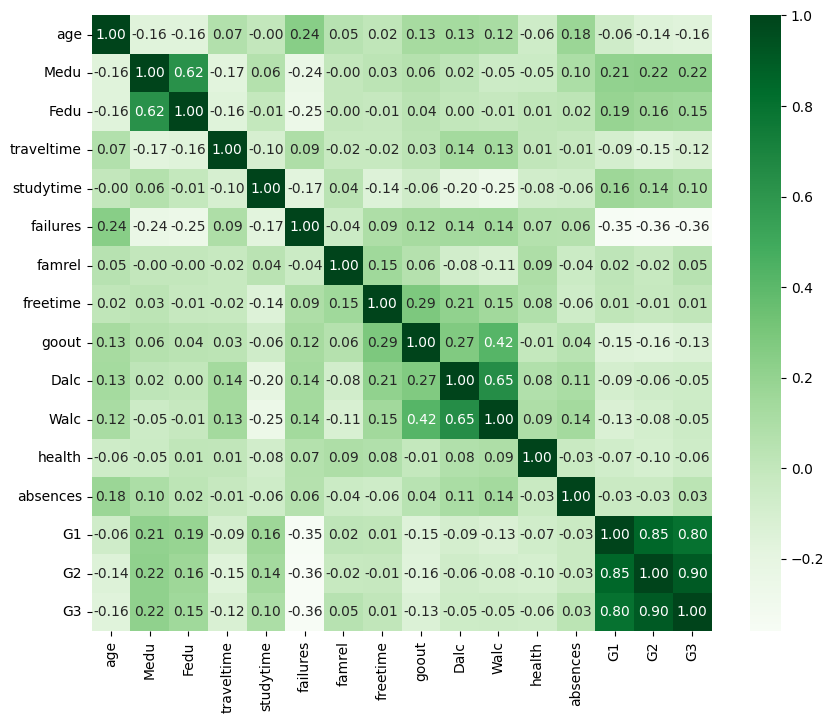

In [100]:
plt.figure(figsize=(10, 8))

corr_matrix = math_perf.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt=".2f")
plt.show()

The strongest coorelations for G3 are with the G1 and G2 as they are previous grades of students. Other high correlations with G3 include failures which is a negative value. This means that a high failure rate tends to relate to lower G3 (on a weaker scale). Mother's and Father's Education are also high in positive correlation to G3 which means children might score higher if their parents are educated well.



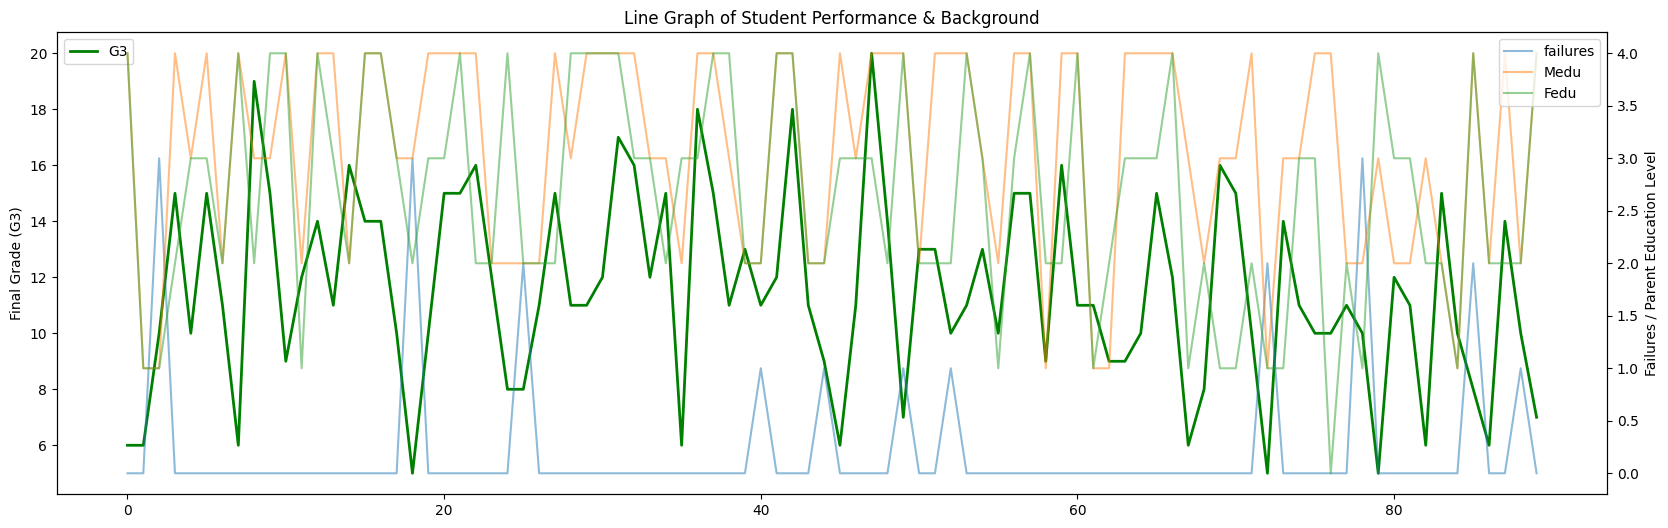

In [101]:
subset = math_perf[['G3', 'failures', 'Medu', 'Fedu']].head(90)

fig, ax1 = plt.subplots(figsize=(20, 6))

ax2 = ax1.twinx()
subset[['failures', 'Medu', 'Fedu']].plot(ax=ax2, alpha=0.5)
subset['G3'].plot(ax=ax1, color='green', linewidth=2, label='G3')

ax1.set_ylabel('Final Grade (G3)')
ax2.set_ylabel('Failures / Parent Education Level')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title("Line Graph of Student Performance & Background")
plt.show()